# **TechWorks CTC Prediction Project**

# **Questions**

## **1. My views about the Problem Statement?**

The goal is to build a machine learning model that predicts the CTC for new hires based on factors like experience, education, previous CTC, and more.

The process involves cleaning the data, handling categorical variables, dealing with outliers, and trying out different regression models to see which one performs the best.

Finally, I want to find a model that gives accurate and consistent predictions while also highlighting which features are the most important for determining the CTC.

## **2. What will be my approach to solving this Task?**

My approach would be:

* **Data Formatting and Cleaning:** I'll start by handling missing values, converting categorical fields into numerical tiers, checking for outliers and creating dummy variables for multi-class categorical varaibles if any.

* **Exploratory Data Analysis (EDA):** Visualize relationships using charts to identify relationships and key features.

* **Model Training:** Then I'll begin with building basic models like Linear Regression and gradually move to more complex methods like Decision Trees, Bagging, and Boosting.

* **Model Comparison:** Evaluate all models based on metrics like R² and MSE, then select the one that performs best for the given data.

* **Final Model Selection:** At last, I'll choose the best model based on performance and interpretability.

## **3. What were the available ML model options I had to perform this Task?**

Here are some of the available options:

* **Linear Regression:** Simple and interpretable, used as a baseline.

* **Ridge and Lasso Regression:** Regularized linear models to handle multicollinearity.

* **Decision Tree Regressor:** Easy to interpret.

* **Bagging Regressor:** Reduces variance by combining multiple Decision Trees.

* **Random Forest Regressor:** An advanced ensemble method that improves accuracy by introducing randomness in features.

* **Gradient Boosting:** Builds trees sequentially to correct errors from previous ones.

* **AdaBoost:** Focuses on misclassified instances and adjusts accordingly.

* **XGBoost:** A powerful, optimized version of Gradient Boosting that often gives superior performance.

For this project, I have used all the methods mentioned above to help predict the CTC for new hires.

## **4. Which model's performance is best and what could be the possible reason for that?**

The best-performing model was **Bagging Regressor** for both basic and tuned versions. The main reasons are:

* Bagging reduces variance effectively by averaging predictions across multiple Decision Trees, leading to a stable and more accurate results.

* Also, it is robust against overfitting.

However, I didn't perform extensive hyper-parameter tuning on boosting methods like **XGBoost** due to computational limitations. It's possible that with deeper tuning, boosting methods could have outperformed Bagging.

## **5. What steps can I take to improve the selected model's performance even further?**

To further improve the model's performance, I could:

* **Feature Engineering:** Generate new features by combining existing ones, for example, using variables like Previous CTC, Experience, and Graduation Marks.

* **Advanced Hyperparameter Tuning:** Perform a more exhaustive grid search or use RandomizedSearchCV for better parameter optimization.

* **Ensemble Stacking:** Combine Bagging with other models like XGBoost or Gradient Boosting to get the best of both worlds.

* **Cross-Validation:** Implement advanced cross-validation techniques like stratified or repeated K-Folds to ensure more robust results.

These steps are straightforward yet effective in enhancing model performance.

# **Importing Libraries**

In [1]:
# Importing numpy for numerical operations and pandas for data manipulation and analysis
import numpy as np
import pandas as pd

# Importing Seaborn and Matplotlib for data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# **Loading the Dataset**

In [ ]:
# Loading the given datasets using pandas read_csv function
df = pd.read_csv("../data/ML_case_Study.csv", header = 0)
college = pd.read_csv("../data/Colleges.csv", header = 0)
cities = pd.read_csv("../data/cities.csv", header = 0)

In [3]:
# Viewing the top 5 rows for df dataset
df.head()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,SVNIT Surat,Asansol,Manager,55523.0,3,66,19,71406.58
1,NIT Bhopal,Ajmer,Executive,57081.0,1,84,18,68005.87
2,"IEM, Kolkata",Rajpur Sonarpur,Executive,60347.0,2,52,28,76764.02
3,"KIIT, Bhubaneswar",Ajmer,Executive,49010.0,2,81,33,82092.39
4,DTU,Durgapur,Executive,57879.0,4,74,32,73878.10


# **Formatting & Cleaning the Data**

In [4]:
# Viewing the first 5 rows of the college dataset
college.head()

,Tier 1,Tier 2,Tier 3
0,IIT Bombay,IIIT Bangalore,"Ramaiah Institute of Technology, Bengaluru"
1,IIT Delhi,IIIT Delhi,TIET/Thapar University
2,IIT Kharagpur,IGDTUW,Manipal Main Campus
3,IIT Madras,NIT Calicut,VIT Vellore
4,IIT Kanpur,IIITM Gwalior,SRM Main Campus


In [5]:
# Creating lists of colleges based on their tiers
Tier1 = college["Tier 1"].tolist()
Tier2 = college["Tier 2"].tolist()
Tier3 = college["Tier 3"].tolist()

In [6]:
# Mapping each college to its corresponding tier and giving them weightage as given in the problem statement
for item in df["College"]:
  if item in Tier1:
    df["College"].replace(item, 1, inplace = True)
  elif item in Tier2:
    df["College"].replace(item, 2, inplace = True)
  elif item in Tier3:
    df["College"].replace(item, 3, inplace = True)

In [7]:
# Viewing the first 5 rows of the cities dataset
cities.head()

,Metrio City,non-metro cities
0,Mumbai,Dehradun
1,Delhi,Durgapur
2,Kolkata,Asansol
3,Chennai,Rourkela
4,Bangalore,Kozhikode


In [8]:
# Creating lists of metro and non-metro cities
metro = cities["Metrio City"].tolist()
non_metro = cities["non-metro cities"].tolist()

In [9]:
# Mapping each city to its corresponding type and assigning 0 for non-metro and 1 for metro cities
for item in df["City"]:
  if item in metro:
    df["City"].replace(item, 1, inplace = True)
  elif item in non_metro:
    df["City"].replace(item, 0, inplace = True)

In [10]:
# Viewing the formatted dataset
df.head()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,2,0,Manager,55523.0,3,66,19,71406.58
1,2,0,Executive,57081.0,1,84,18,68005.87
2,3,0,Executive,60347.0,2,52,28,76764.02
3,3,0,Executive,49010.0,2,81,33,82092.39
4,1,0,Executive,57879.0,4,74,32,73878.10


### **Checking for Null values**

In [11]:
# Viewing the summary of the dataset which includes information like count of non-null values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   College              1589 non-null   int64  
 1   City                 1589 non-null   int64  
 2   Role                 1589 non-null   object 
 3   Previous CTC         1589 non-null   float64
 4   Previous job change  1589 non-null   int64  
 5   Graduation Marks     1589 non-null   int64  
 6   EXP (Month)          1589 non-null   int64  
 7   CTC                  1589 non-null   float64
dtypes: float64(2), int64(5), object(1)
memory usage: 99.4+ KB


**Output shows that no null values are present in the dataset.**

### **Creating Dummy Variables**

In [12]:
# Since we know that the number of dummy variables should be one less than the number of categories, so we'll remove the extra column using drop_first parameter.
df = pd.get_dummies(df, columns = ["Role"], drop_first = True, dtype = int)

df.head()

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
0,2,0,55523.0,3,66,19,71406.58,1
1,2,0,57081.0,1,84,18,68005.87,0
2,3,0,60347.0,2,52,28,76764.02,0
3,3,0,49010.0,2,81,33,82092.39,0
4,1,0,57879.0,4,74,32,73878.10,0


# **Performing EDD**

In [13]:
# Looking at the summary statistics for the numerical columns to check for any outliers
df.describe()

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
count,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,1.975456,0.514160,55518.453744,2.528634,59.855255,39.044682,75353.278798,0.206419
std,0.838330,0.499957,6655.218445,1.123918,14.935139,14.108875,12587.288237,0.404862
min,1.000000,0.000000,36990.000000,1.000000,35.000000,18.000000,53020.320000,0.000000
25%,1.000000,0.000000,50518.000000,2.000000,46.000000,26.000000,66902.350000,0.000000
50%,2.000000,1.000000,55291.000000,3.000000,60.000000,39.000000,73028.670000,0.000000
75%,3.000000,1.000000,60109.000000,4.000000,73.000000,51.000000,80588.670000,0.000000
max,3.000000,1.000000,77911.000000,4.000000,85.000000,64.000000,123416.990000,1.000000


We can see from the distribution for *Previous CTC* and *CTC* column, that although there are no major outliers, there may be some outliers present in these columns.

### **Outlier Treatment**

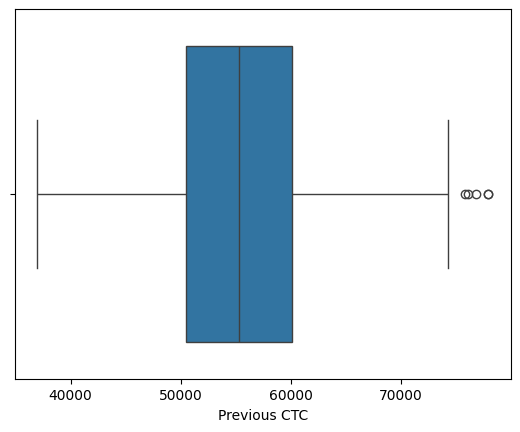

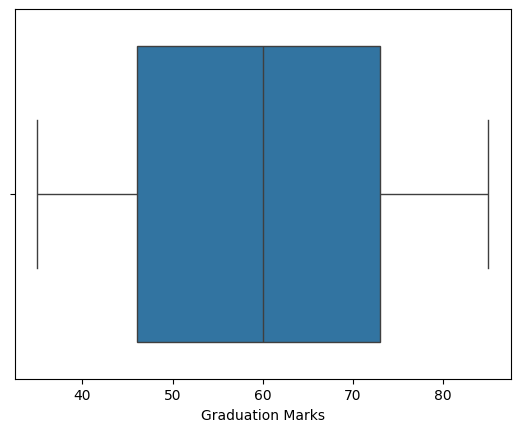

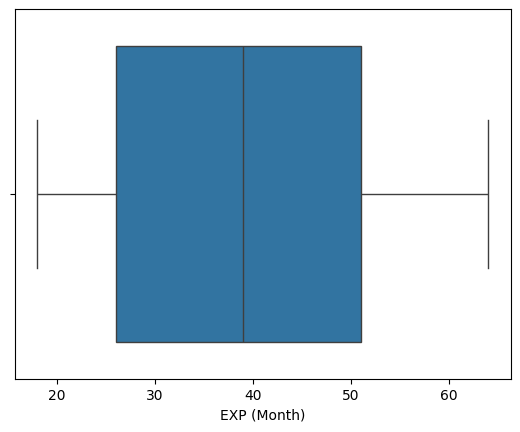

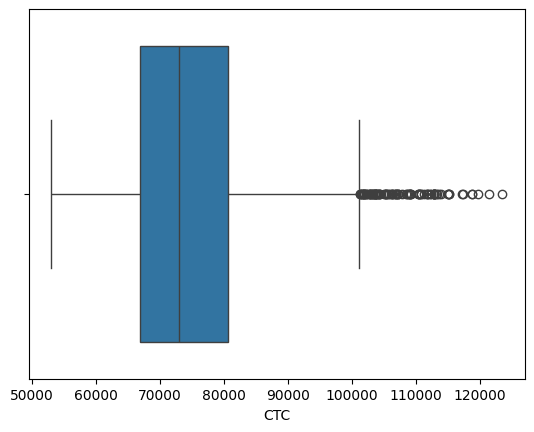

In [14]:
# List of columns to exclude from outlier analysis (categorical and irrelevant for outlier detection)
excluded_columns = ["College", "City", "Previous job change", "Role_Manager"]

# Looping through columns and plotting boxplot for non-excluded ones, as boxplot helps visualize the spread of data and detect outliers
for col in df.select_dtypes(include = "number").columns:
    if col not in excluded_columns:
        sns.boxplot(x = df[col])
        plt.show()

We can see that *Previous CTC* and *CTC* column do have outliers, which is clearly visible through the **Box Plot**.

In [15]:
# Calculating the Interquartile Range (IQR) for "Previous CTC" and "CTC" to handle outliers
Q1 = df[["Previous CTC", "CTC"]].quantile(0.25)    # 25th percentile (lower quartile)
Q3 = df[["Previous CTC", "CTC"]].quantile(0.75)    # 75th percentile (upper quartile)

# Interquartile Range
IQR = Q3 - Q1

# Defining the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Replacing outliers above and below the defined bounds with the nearest bound
for col in ["Previous CTC", "CTC"]:
    df[col] = np.where(df[col] > upper_bound[col], upper_bound[col], df[col])
    df[col] = np.where(df[col] < lower_bound[col], lower_bound[col], df[col])

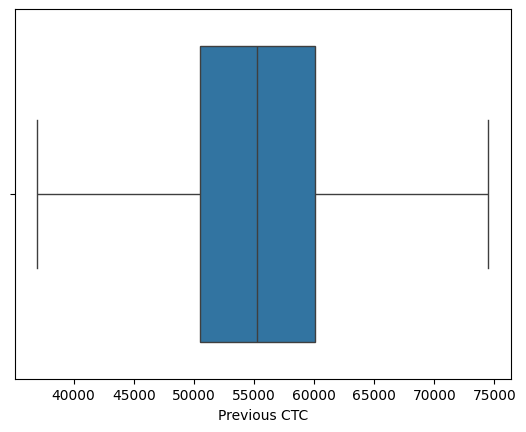

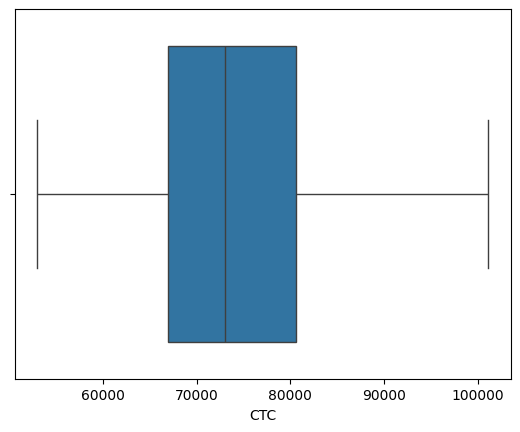

In [16]:
# Rechecking the boxplots after outlier treatment to see if the outliers are removed or not
for col in ["Previous CTC", "CTC"]:
  sns.boxplot(x = df[col])
  plt.show()

We can see that we have succesfully removed the outliers from the data. Although, one thing to note is here that, these outliers were not extreme in any way. So we can consult with our organization, on whether to treat those outliers, or let them as they are.

In [17]:
# Looking at the summary statistics after outliers removal
df.describe()

,College,City,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Role_Manager
count,1589.000000,1589.000000,1589.00000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,1.975456,0.514160,55510.89270,2.528634,59.855255,39.044682,74949.456306,0.206419
std,0.838330,0.499957,6632.04596,1.123918,14.935139,14.108875,11536.548461,0.404862
min,1.000000,0.000000,36990.00000,1.000000,35.000000,18.000000,53020.320000,0.000000
25%,1.000000,0.000000,50518.00000,2.000000,46.000000,26.000000,66902.350000,0.000000
50%,2.000000,1.000000,55291.00000,3.000000,60.000000,39.000000,73028.670000,0.000000
75%,3.000000,1.000000,60109.00000,4.000000,73.000000,51.000000,80588.670000,0.000000
max,3.000000,1.000000,74495.50000,4.000000,85.000000,64.000000,101118.150000,1.000000


### **Checking Distribution of Variables**


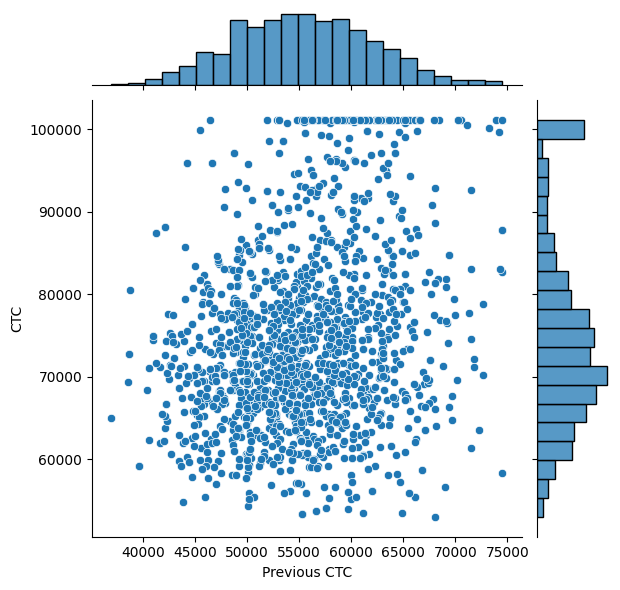

In [18]:
# Analyzing the relationship between "Previous CTC" and "CTC" using a joint plot
sns.jointplot(data = df, x = "Previous CTC", y = "CTC")
plt.show()

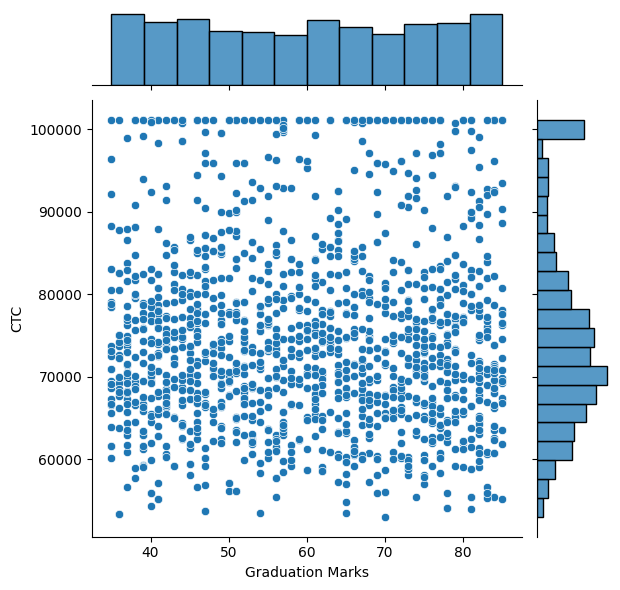

In [19]:
# Analyzing the relationship between "Graduation Marks" and "CTC"
sns.jointplot(data = df, x = "Graduation Marks", y = "CTC")
plt.show()

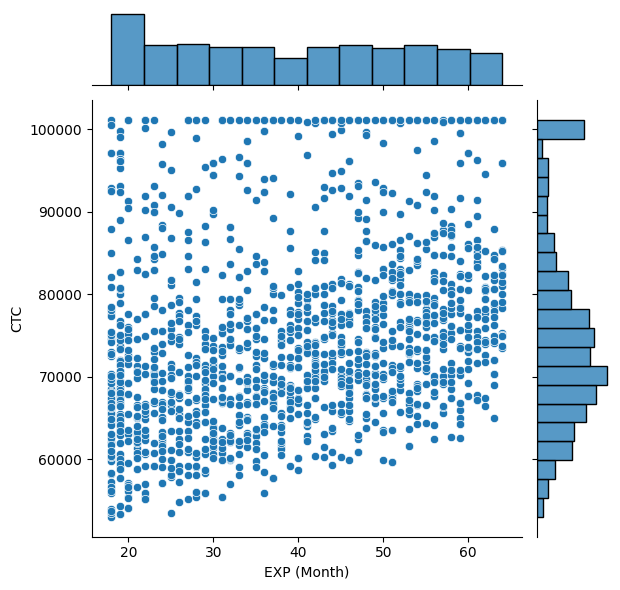

In [20]:
# Analyzing the relationship between "EXP (Month)" and "CTC"
sns.jointplot(data = df, x = "EXP (Month)", y = "CTC")
plt.show()

By seeing these distributions, it is clear that there is no clear linear relationship between these independent variables with our dependent variable *CTC*.

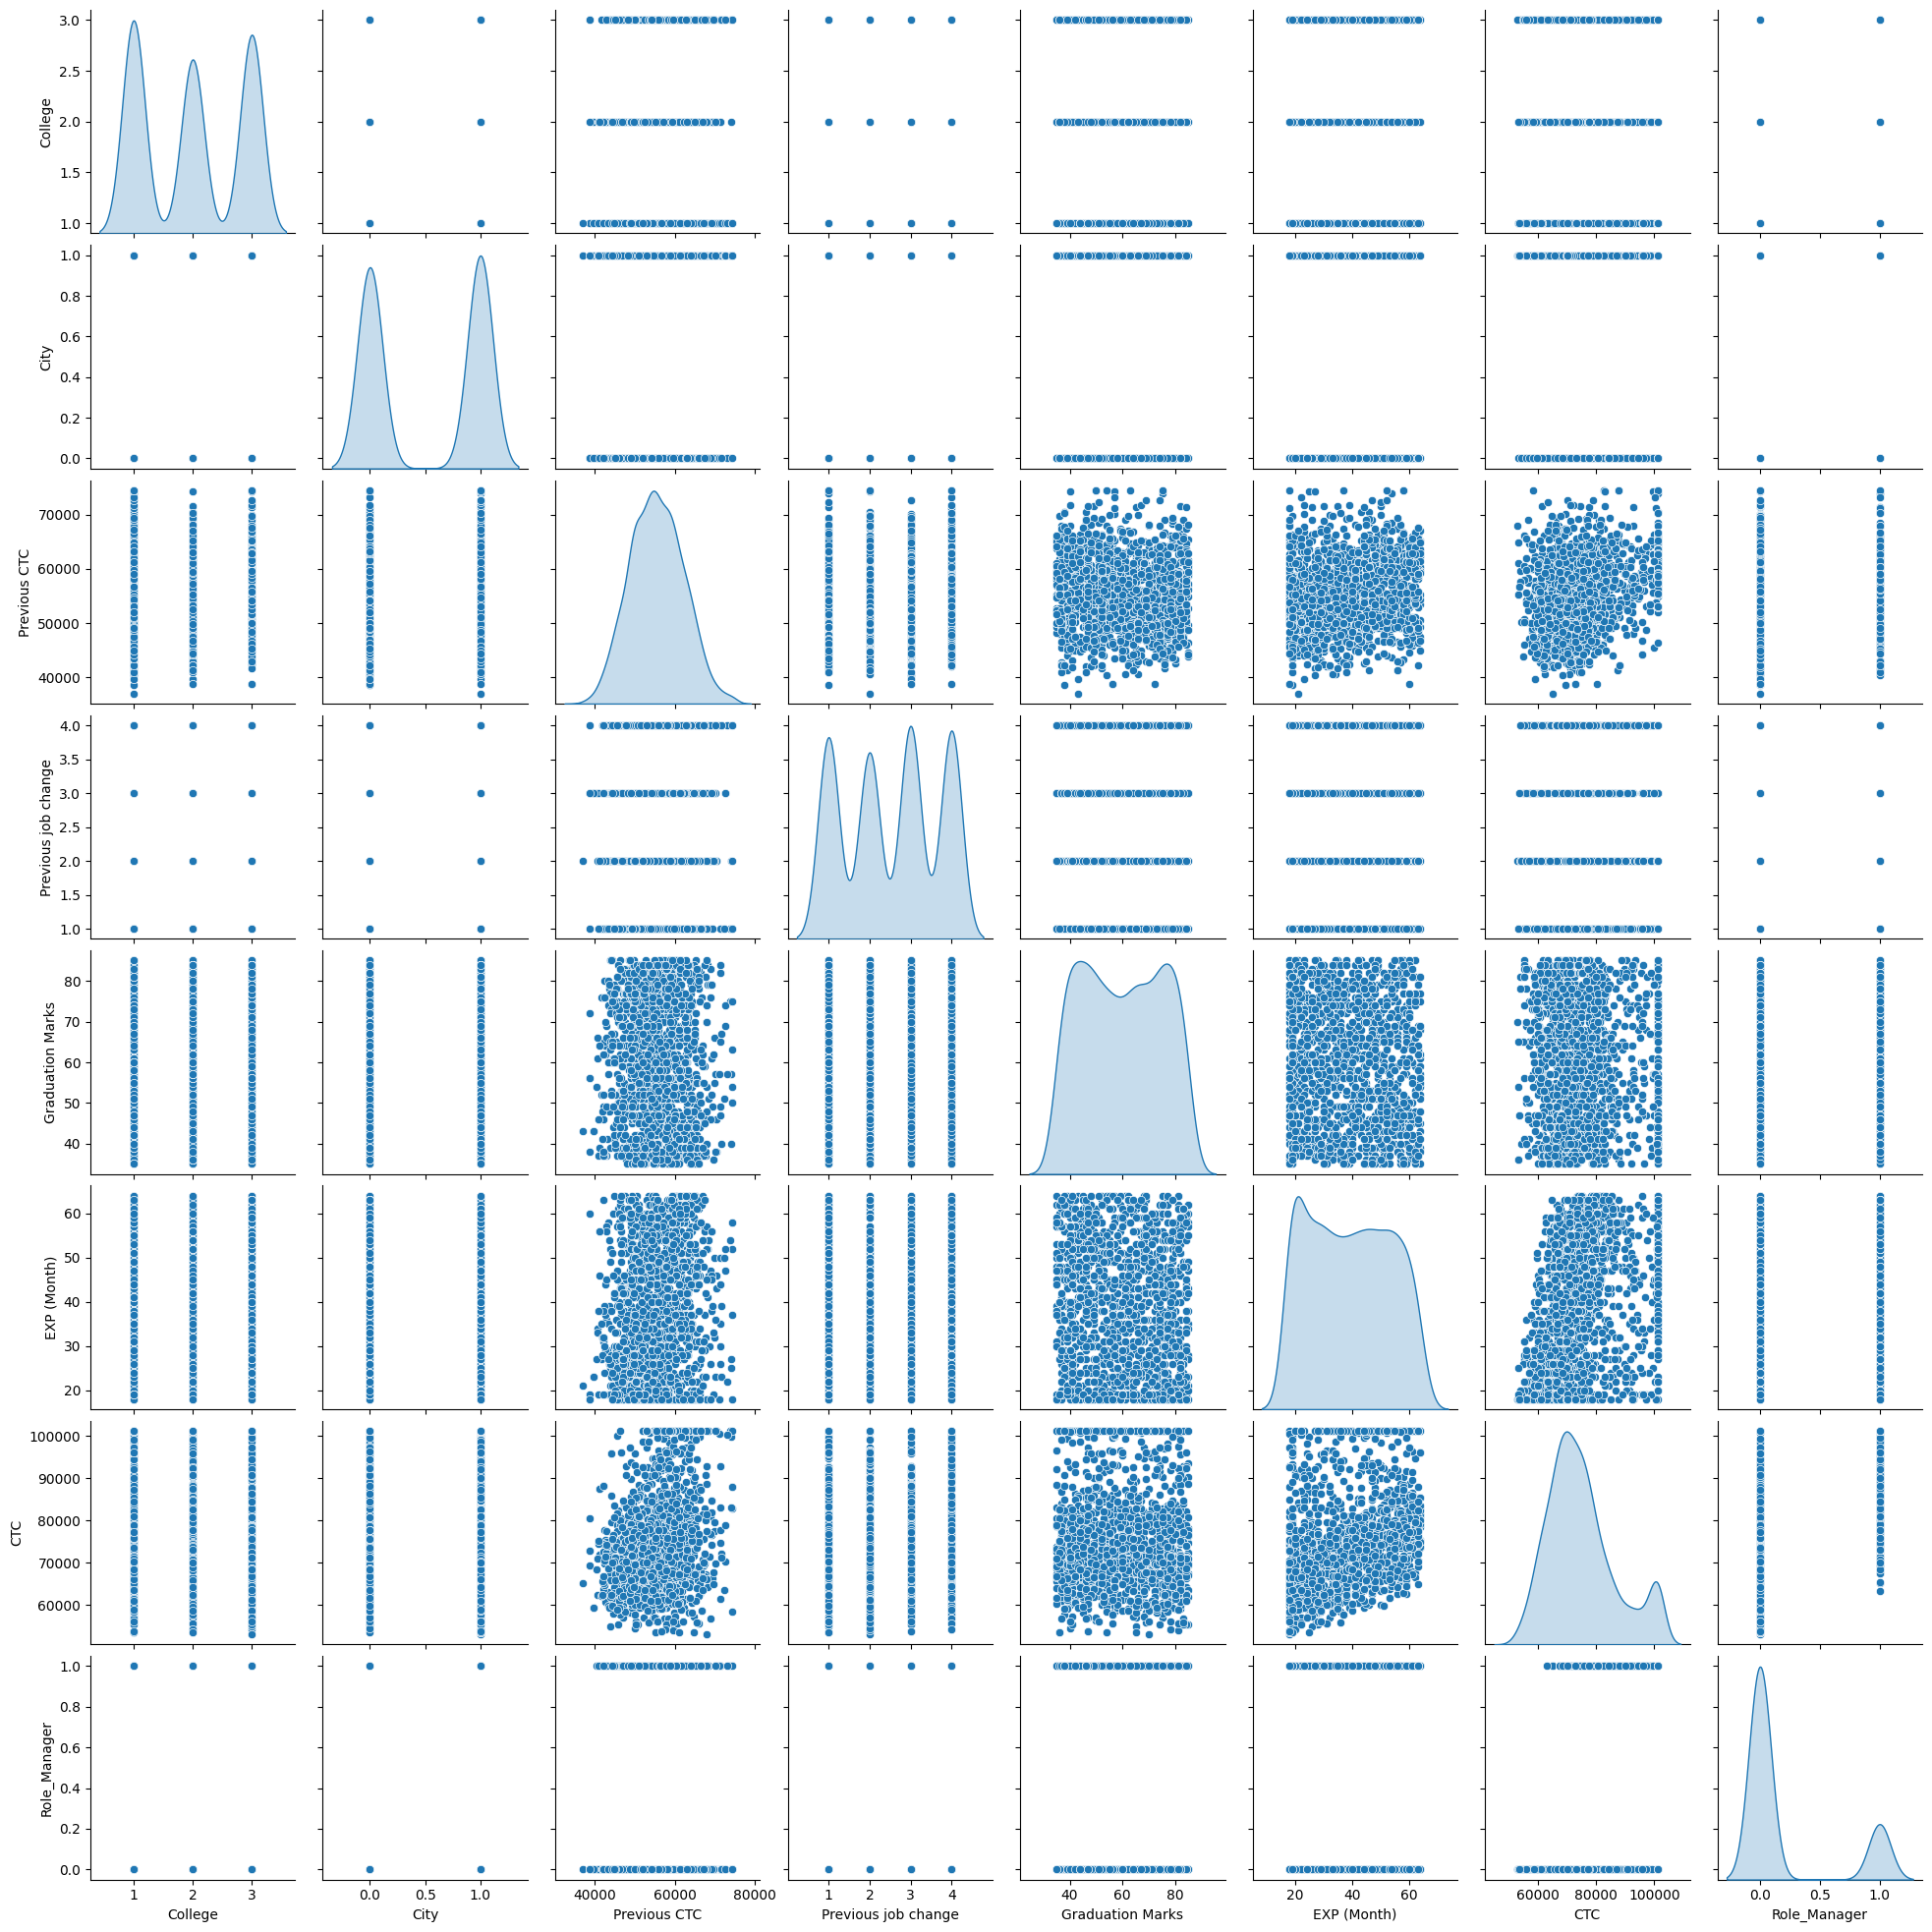

In [21]:
# Plotting pair plot graph for all numerical variables with KDE (Kernel Density Estimate) on the diagonal
sns.pairplot(data = df, diag_kind = "kde")
plt.show()

### **Correlation Analysis**

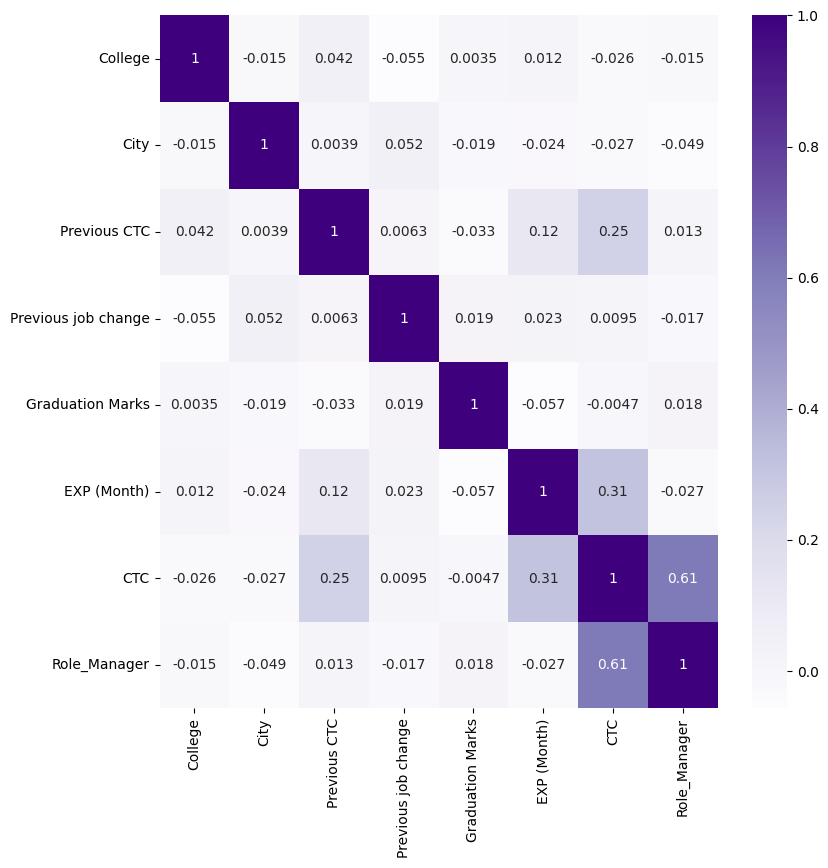

In [22]:
# Plotting a heatmap to visualize the correlation matrix
plt.figure(figsize = (9, 9))

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True, cmap = "Purples")
plt.show()

* The correlation between *CTC* and *Role_Manager* is notably high at **0.61**. This is expected, as managerial positions typically come with higher compensation compared to executive roles due to increased responsibilities and competitive salary standards for such positions.

* The correlation between *CTC* and *Previous CTC* is relatively weak at **0.25**, while *CTC* and *EXP (Month)* have a slightly higher, but still weak, correlation of **0.31**. These correlations suggest that neither previous CTC nor experience strongly influences the *CTC* variable.

* Next, we can also see that there is no other significant correlation between any of the independent variables.

# **Data Pre-processing**

### **Dependent- Independent Data Split**

In [23]:
# Splitting the data into independent (X) and dependent variable (y)
X = df.loc[:, df.columns != "CTC"]
y = df["CTC"]

In [24]:
# Checking the shape of the independent and dependent variables
print(X.shape, y.shape)

(1589, 7) (1589,)


### **Train-Test Split**

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
# Splitting the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Checking the shape of train-test splits
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1271, 7) (318, 7) (1271,) (318,)


# **Linear Regression**

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
# Initializing and training a simple Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [29]:
from sklearn.metrics import r2_score, mean_squared_error

In [30]:
# Calculating the R² and MSE scores for the test set predictions
lin_reg_r2 = r2_score(y_test, lin_reg.predict(X_test))
lin_reg_mse = mean_squared_error(y_test, lin_reg.predict(X_test))

print("Test R² Score:", lin_reg_r2)
print("Test MSE:", lin_reg_mse)

Test R² Score: 0.5790435058024472
Test MSE: 66013643.899601676


# **Ridge Regression**

### **Standardizing the Data**

We need to standardize our data before running Ridge and Lasso Regression because these models are sensitive to feature scaling.

In [31]:
from sklearn import preprocessing

In [32]:
# Fitting the StandardScaler to the training data and applying the transformation
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train) # Scaled training data

In [33]:
# Fitting the StandardScaler to the test data and applying the transformation
scaler = preprocessing.StandardScaler().fit(X_test)
X_test_s = scaler.transform(X_test) # Scaled test data

Importing the Ridge Library from sklearn to perform Ridge Regression

In [34]:
from sklearn.linear_model import Ridge

In [35]:
# Creating a Ridge model object with alpha = 1 and fitting the data
rid_reg = Ridge(alpha = 1)
rid_reg.fit(X_train_s, y_train)

Ridge(alpha=1)

In [36]:
# Calculating the R² and MSE scores for the initial Ridge Regression model
rid_reg_int_r2 = r2_score(y_test, rid_reg.predict(X_test_s))
rid_reg_int_mse = mean_squared_error(y_test, rid_reg.predict(X_test_s))

# Displaying the initial performance metrics for Ridge Regression
print("Initial Test R² Score:", rid_reg_int_r2)
print("Initial Test MSE:", rid_reg_int_mse)

Initial Test R² Score: 0.5757464369159249
Initial Test MSE: 66530684.34056754


### **Fine Tuning Ridge Regression using RidgeCV**



In [37]:
from sklearn.linear_model import RidgeCV

In [38]:
# Defining a range of alpha values to test
alphas = np.linspace(0.1, 10, 100)

In [39]:
# Creating a RidgeCV model object with cross-validation and fitting the data
rid_reg_cv = RidgeCV(alphas = alphas, cv = 5)         # cv = 5 indicates 5-fold cross-validation
rid_reg_cv.fit(X_train_s, y_train)

RidgeCV(alphas=array([ 0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,
        1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,
        2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,
        3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,
        4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,  5.5,
        5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,  6.6,
        6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,  7.7,
        7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,  8.8,
        8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9,
       10. ]),
        cv=5)

In [40]:
# Checking and printing the best alpha value found during cross-validation
print("Best alpha:", rid_reg_cv.alpha_)

Best alpha: 6.4


In [41]:
# Calculating the R² and MSE scores for the optimized Ridge model
rid_reg_opt_r2 = r2_score(y_test, rid_reg_cv.predict(X_test_s))
rid_reg_opt_mse = mean_squared_error(y_test, rid_reg_cv.predict(X_test_s))

# Displaying the optimized performance metrics for Ridge Regression
print("Optimized Test R² Score:", rid_reg_opt_r2)
print("Optimized Test MSE:", rid_reg_opt_mse)

Optimized Test R² Score: 0.5749922428103176
Optimized Test MSE: 66648955.7101865


# **Lasso Regression**

As we have already standardized our data, we will now import the Lasso Library from sklearn to perform Lasso Regression in a similar method by which we performed Ridge Regression.

In [42]:
from sklearn.linear_model import Lasso

In [43]:
# Creating a Lasso model object with alpha = 1 and fitting the data
las_reg = Lasso(alpha = 1)
las_reg.fit(X_train_s, y_train)

Lasso(alpha=1)

In [44]:
# Evaluating the Lasso model on the test data
las_reg_int_r2 = r2_score(y_test, las_reg.predict(X_test_s))
las_reg_int_mse = mean_squared_error(y_test, las_reg.predict(X_test_s))

# Displaying the initial performance metrics for Lasso Regression
print("Initial Test R² Score:", las_reg_int_r2)
print("Initial Test MSE:", las_reg_int_mse)

Initial Test R² Score: 0.5758699857205684
Initial Test MSE: 66511309.63817815


### **Fine Tuning Lasso Regression using LassoCV**

In [45]:
from sklearn.linear_model import LassoCV

In [46]:
# Defining a range of alpha values to test
alphas = np.linspace(0.1, 10, 100)

In [47]:
# Creating a RidgeCV model object with cross-validation and fitting the data
las_reg_cv = LassoCV(alphas = alphas, cv = 5)
las_reg_cv.fit(X_train_s, y_train)

LassoCV(alphas=array([ 0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,
        1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,
        2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,
        3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,
        4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,  5.5,
        5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,  6.6,
        6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,  7.7,
        7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,  8.8,
        8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9,
       10. ]),
        cv=5)

In [48]:
# Checking and printing the best alpha value found during cross-validation
print("Best alpha:", las_reg_cv.alpha_)

Best alpha: 10.0


In [49]:
# Evaluating the optimized Lasso model on the test data
las_reg_opt_r2 = r2_score(y_test, las_reg_cv.predict(X_test_s))
las_reg_opt_mse = mean_squared_error(y_test, las_reg_cv.predict(X_test_s))

# Displaying the optimized performance metrics for Lasso Regression
print("Optimized Test R² Score:", las_reg_opt_r2)
print("Optimized Test MSE:", las_reg_opt_mse)

Optimized Test R² Score: 0.5757282799730845
Optimized Test MSE: 66533531.679842465


# **K-Nearest Neighbors (KNN) Regressor**

In [50]:
# Importing the K-Nearest Neighbors Regressor
from sklearn.neighbors import KNeighborsRegressor

In [51]:
# Defining and fitting a simple KNN model with n_neighbors = 3
knn_reg = KNeighborsRegressor(n_neighbors = 3)
knn_reg.fit(X_train_s, y_train)

KNeighborsRegressor(n_neighbors=3)

In [52]:
# Evaluating the KNN model on the test data
knn_reg_int_r2 = r2_score(y_test, knn_reg.predict(X_test_s))
knn_reg_int_mse = mean_squared_error(y_test, knn_reg.predict(X_test_s))

# Displaying the initial performance metrics for KNN Regression
print("Initial Test R² Score:", knn_reg_int_r2)
print("Initial Test MSE:", knn_reg_int_mse)

Initial Test R² Score: 0.5257074606360617
Initial Test MSE: 74377707.0300175


### **Fine Tuning KNN Regressor using GridSearchCV**

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
# Defining the parameter grid for GridSearchCV
param_grid = {"n_neighbors": list(range(1, 31))}

# Setting up GridSearchCV
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv = 5, scoring = "r2")
grid_search.fit(X_train_s, y_train)

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'n_neighbors': 21}


In [55]:
# Creating the KNN model with the best parameters found
best_knn_reg = grid_search.best_estimator_

# Fitting the optimized KNN model on the training data
best_knn_reg.fit(X_train_s, y_train)

KNeighborsRegressor(n_neighbors=21)

In [56]:
# Evaluating the optimized KNN model on the test data
knn_reg_opt_r2 = r2_score(y_test, best_knn_reg.predict(X_test_s))
knn_reg_opt_mse = mean_squared_error(y_test, best_knn_reg.predict(X_test_s))

# Displaying the optimized performance metrics for KNN Regression
print("Optimized Test R² Score:", knn_reg_opt_r2)
print("Optimized Test MSE:", knn_reg_opt_mse)

Optimized Test R² Score: 0.5837533505677415
Optimized Test MSE: 65275054.47422362


# **Decision Tree Regressor**

In [57]:
from sklearn import tree

As we don't want to overfit our tree, so we will take the *max_depth* to be 3.

In [58]:
# Creating regressor object and fitting data into it
regtree = tree.DecisionTreeRegressor(max_depth = 3)
regtree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [59]:
# Evaluating the initial Decision Tree model
regtree_int_r2 = r2_score(y_test, regtree.predict(X_test))
regtree_int_mse = mean_squared_error(y_test, regtree.predict(X_test))

# Displaying the initial performance metrics for Tree Regressor
print("Initial Test R² Score:", regtree_int_r2)
print("Initial Test MSE:", regtree_int_mse)

Initial Test R² Score: 0.5848863588988698
Initial Test MSE: 65097378.13584341


### **Visualizing the Decision Tree**

In [60]:
from IPython.display import Image
import pydotplus

In [61]:
# Export the decision tree structure in DOT format using Graphviz
dot_data = tree.export_graphviz(regtree, out_file = None, feature_names = X_train.columns, filled = True, rounded = True)

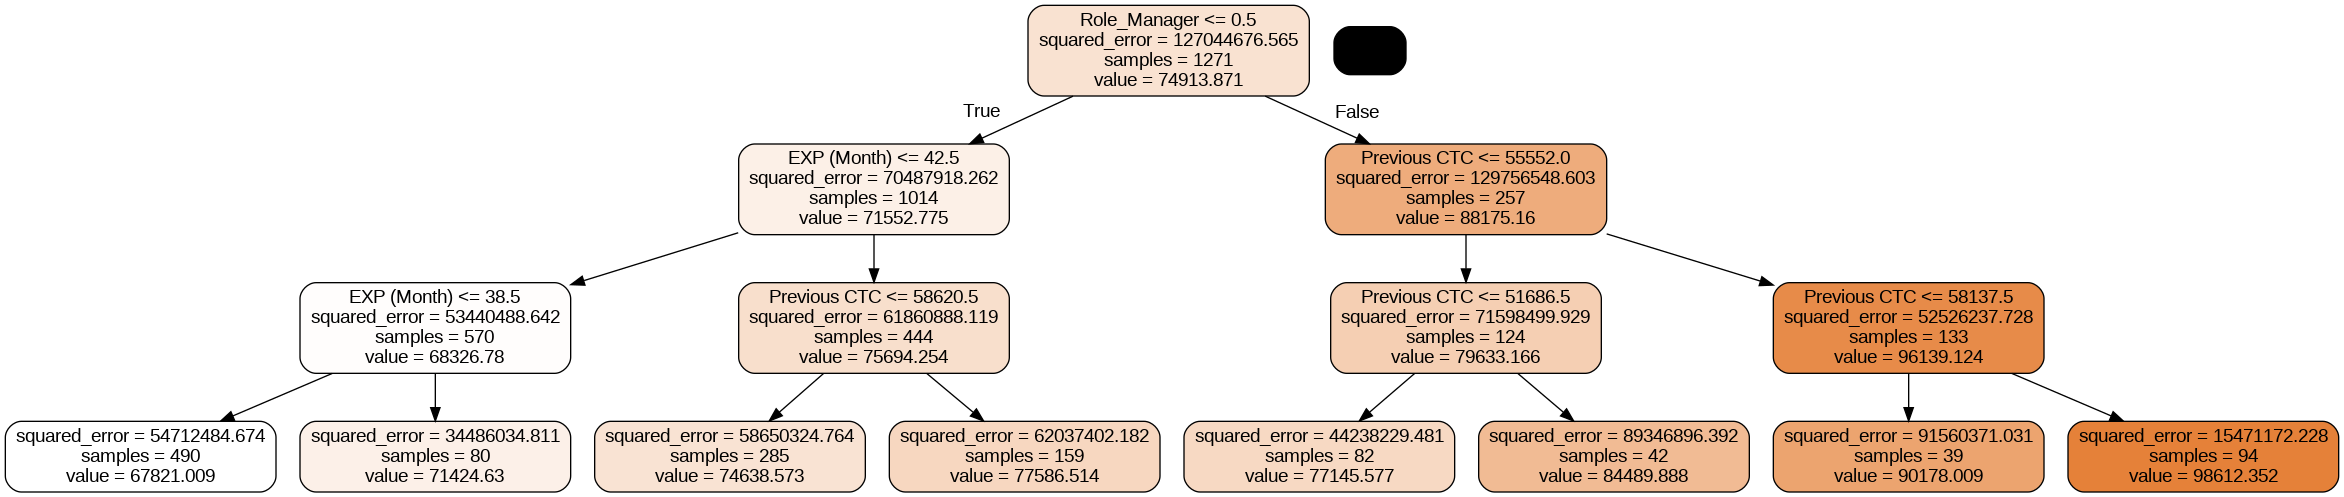

In [62]:
# Displaying decision tree as an image
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

### **Fine Tuning Decision Tree Regressor using GridSearchCV**

We need to keep note that, in order to make our tree interpretable, we should not excede the *max_depth* values beyond 5.

In [63]:
# Creating a default DecisionTreeRegressor object
regtree = tree.DecisionTreeRegressor()

In [64]:
# Defining the parameter grid for GridSearchCV
param_grid = {"max_depth": [1, 2, 3, 4, 5], "min_samples_split": [5, 10, 15, 20], "min_samples_leaf": [1, 2, 3, 5, 10]}

# GridSearchCV for Decision Tree
grid_search_dt = GridSearchCV(regtree, param_grid, cv = 5, scoring = "r2")
grid_search_dt.fit(X_train, y_train)

# Creating the model with the best parameters
regtree_best = grid_search_dt.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search_dt.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 10}


In [65]:
# Evaluating the model with the optimized parameters
regtree_opt_r2 = r2_score(y_test, regtree_best.predict(X_test))
regtree_opt_mse = mean_squared_error(y_test, regtree_best.predict(X_test))

# Displaying the optimized performance metrics for Tree Regressor
print("Optimized Test R² Score:", regtree_opt_r2)
print("Optimized Test MSE:", regtree_opt_mse)

Optimized Test R² Score: 0.5888205401273736
Optimized Test MSE: 64480426.87785174


### **Visualizing the Optimized Decision Tree**

In [66]:
# Export the decision tree structure in DOT format using Graphviz
dot_data_optimized = tree.export_graphviz(regtree_best, out_file = None, feature_names = X_train.columns, filled = True, rounded = True)

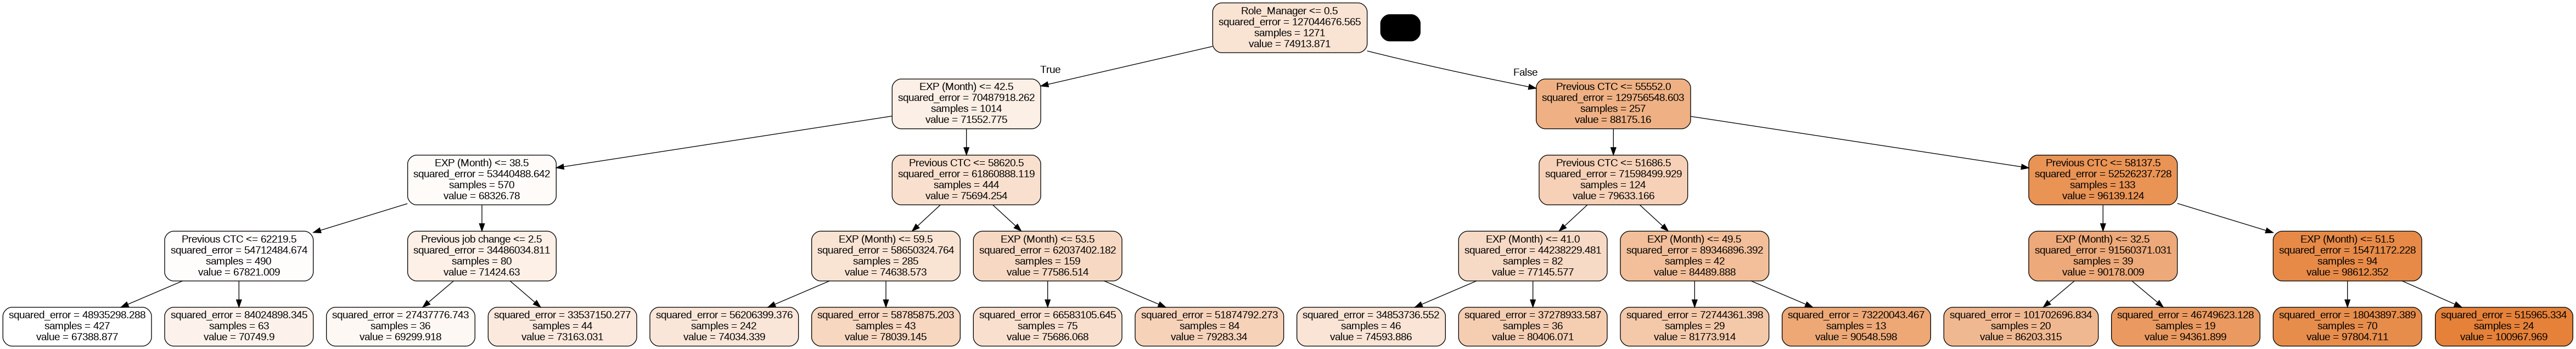

In [67]:
# Displaying decision tree as an image
graph_optimized = pydotplus.graph_from_dot_data(dot_data_optimized)
Image(graph_optimized.create_png())

# **Bagging Regressor**

In [68]:
from sklearn.ensemble import BaggingRegressor

# Creating a base Decision Tree for the Bagging Regressor
regtree = tree.DecisionTreeRegressor()

In [69]:
# Basic Bagging Regressor
bag_reg = BaggingRegressor(estimator = regtree, n_estimators = 25, n_jobs = -1, random_state = 42)
bag_reg.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=25, n_jobs=-1,
                 random_state=42)

In [70]:
# Evaluating the initial Bagging Regressor model
bag_reg_int_r2 = r2_score(y_test, bag_reg.predict(X_test))
bag_reg_int_mse = mean_squared_error(y_test, bag_reg.predict(X_test))

print("Initial Test R² Score:", bag_reg_int_r2)
print("Initial Test MSE:", bag_reg_int_mse)

Initial Test R² Score: 0.6134801600248392
Initial Test MSE: 60613349.42673899


### **Fine Tuning Bagging Regressor using GridSearchCV**

In [71]:
# Defining the parameter grid for GridSearchCV
param_grid = {"n_estimators": [50, 100, 200], "max_samples": [0.8, 0.9]}

# GridSearchCV for Bagging Regressor
grid_search_bag = GridSearchCV(bag_reg, param_grid, cv = 5, scoring = "r2")
grid_search_bag.fit(X_train, y_train)

# Creating the model with the best parameters
bag_reg_best = grid_search_bag.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search_bag.best_params_)

Best Parameters: {'max_samples': 0.9, 'n_estimators': 200}


In [72]:
# Evaluating the model with the optimized parameters
bag_reg_opt_r2 = r2_score(y_test, bag_reg_best.predict(X_test))
bag_reg_opt_mse = mean_squared_error(y_test, bag_reg_best.predict(X_test))

print("Optimized Test R² Score:", bag_reg_opt_r2)
print("Optimized Test MSE:", bag_reg_opt_mse)

Optimized Test R² Score: 0.6285490824278357
Optimized Test MSE: 58250267.98917051


# **Random Forest Regressor**

In [73]:
from sklearn.ensemble import RandomForestRegressor

In [74]:
# Basic Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators = 25, n_jobs = -1, random_state = 42)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(n_estimators=25, n_jobs=-1, random_state=42)

In [75]:
# Evaluating the model
rf_reg_int_r2 = r2_score(y_test, rf_reg.predict(X_test))
rf_reg_int_mse = mean_squared_error(y_test, rf_reg.predict(X_test))

print("Initial Test R² Score:", rf_reg_int_r2)
print("Initial Test MSE:", rf_reg_int_mse)

Initial Test R² Score: 0.6100852066444143
Initial Test MSE: 61145739.93882346


### **Fine Tuning Random Forest Regressor using GridSearchCV**

In [76]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [50, 75, 100],
    "max_features": [3, 4],
    "max_depth": [4, 5],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 3]
    }

# GridSearchCV for Random Forest Regressor
grid_search_rf = GridSearchCV(rf_reg, param_grid, cv = 5, scoring = "r2")
grid_search_rf.fit(X_train, y_train)

# Creating the model with the best parameters
rf_reg_best = grid_search_rf.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search_rf.best_params_)

Best Parameters: {'max_depth': 5, 'max_features': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [77]:
# Evaluating the model with the optimized parameters
rf_reg_opt_r2 = r2_score(y_test, rf_reg_best.predict(X_test))
rf_reg_opt_mse = mean_squared_error(y_test, rf_reg_best.predict(X_test))

print("Optimized Test R² Score:", rf_reg_opt_r2)
print("Optimized Test MSE:", rf_reg_opt_mse)

Optimized Test R² Score: 0.6087126279517134
Optimized Test MSE: 61360985.27246977


# **Gradient Boosting**

In [78]:
from sklearn.ensemble import GradientBoostingRegressor

In [79]:
# Basic Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor()
gb_reg.fit(X_train, y_train)

GradientBoostingRegressor()

In [80]:
# Evaluating the model
gb_reg_int_r2 = r2_score(y_test, gb_reg.predict(X_test))
gb_reg_int_mse = mean_squared_error(y_test, gb_reg.predict(X_test))

print("Initial Test R² Score:", gb_reg_int_r2)
print("Initial Test MSE:", gb_reg_int_mse)

Initial Test R² Score: 0.6047156517142017
Initial Test MSE: 61987783.93136977


### **Fine Tuning Gradient Boost using GridSearchCV**

In [81]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 4]
    }

# GridSearchCV for Gradient Boosting Regressor
grid_search_gb = GridSearchCV(gb_reg, param_grid, cv = 5, scoring = "r2")
grid_search_gb.fit(X_train, y_train)

# Creating the model with the best parameters
gb_reg_best = grid_search_gb.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search_gb.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}


In [82]:
# Evaluating the model with the optimized parameters
gb_reg_opt_r2 = r2_score(y_test, gb_reg_best.predict(X_test))
gb_reg_opt_mse = mean_squared_error(y_test, gb_reg_best.predict(X_test))

print("Optimized Test R² Score:", gb_reg_opt_r2)
print("Optimized Test MSE:", gb_reg_opt_mse)

Optimized Test R² Score: 0.6033260309297281
Optimized Test MSE: 62205701.77534221


# **Ada Boost**

In [83]:
from sklearn.ensemble import AdaBoostRegressor

In [84]:
# Basic AdaBoost Regressor
ada_reg = AdaBoostRegressor()
ada_reg.fit(X_train, y_train)

AdaBoostRegressor()

In [85]:
# Evaluating the model
ada_reg_int_r2 = r2_score(y_test, ada_reg.predict(X_test))
ada_reg_int_mse = mean_squared_error(y_test, ada_reg.predict(X_test))

print("Initial Test R² Score:", ada_reg_int_r2)
print("Initial Test MSE:", ada_reg_int_mse)

Initial Test R² Score: 0.5686002856933545
Initial Test MSE: 67651330.98353887


### **Fine Tuning Ada Boost using GridSearchCV**

In [86]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1]
    }

# GridSearchCV for Ada Boosting Regressor
grid_search_ada = GridSearchCV(ada_reg, param_grid, cv = 5, scoring = "r2")
grid_search_ada.fit(X_train, y_train)

# Creating the model with the best parameters
ada_reg_best = grid_search_ada.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search_ada.best_params_)

Best Parameters: {'learning_rate': 0.01, 'n_estimators': 50}


In [87]:
# Evaluating the model with the optimized parameters
ada_reg_opt_r2 = r2_score(y_test, ada_reg_best.predict(X_test))
ada_reg_opt_mse = mean_squared_error(y_test, ada_reg_best.predict(X_test))

print("Optimized Test R² Score:", ada_reg_opt_r2)
print("Optimized Test MSE:", ada_reg_opt_mse)

Optimized Test R² Score: 0.6044048243895942
Optimized Test MSE: 62036527.316027656


# **XG Boost**

In [88]:
import xgboost as xgb

In [89]:
# Basic XGBoost Regressor
xgb_reg = xgb.XGBRegressor(n_estimators = 100, max_depth = 3, learning_rate = 0.1, n_jobs = -1, random_state = 42)
xgb_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [90]:
# Evaluating the model
xgb_reg_int_r2 = r2_score(y_test, xgb_reg.predict(X_test))
xgb_reg_int_mse = mean_squared_error(y_test, xgb_reg.predict(X_test))

print("Initial Test R² Score:", xgb_reg_int_r2)
print("Initial Test MSE:", xgb_reg_int_mse)

Initial Test R² Score: 0.5999707809910482
Initial Test MSE: 62731866.064762175


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

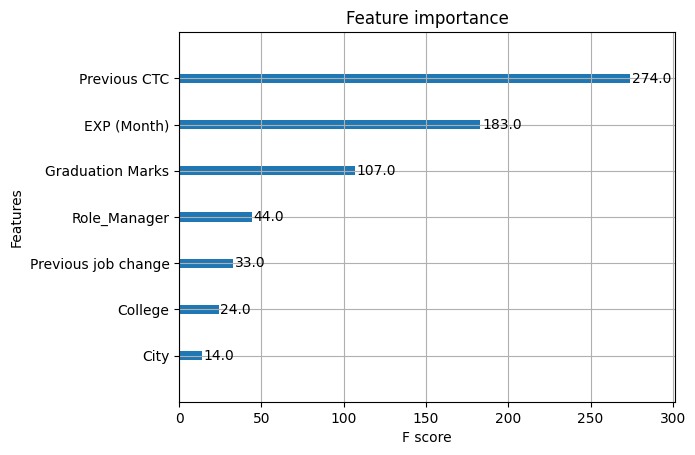

In [91]:
# Plotting feature importance for the trained XGBoost model
xgb.plot_importance(xgb_reg)

According to the XGBoost model, *Previous CTC* is the most important factor in predicting salary. It is followed by *EXP (Month)* and *Graduation Marks*.

This indicates that the previous compensation and experience of work significantly impact salary predictions, while academic performance also plays a noteworthy role.

### **Fine Tuning XG Boost using GridSearchCV**

In [92]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [75, 100, 250],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "gamma": [0.1, 0.2],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "reg_alpha": [1e-2, 0.1, 1]
    }

# GridSearchCV for XG Boost Regressor
grid_search_xgb = GridSearchCV(xgb_reg, param_grid, cv = 5, scoring = "r2")
grid_search_xgb.fit(X_train, y_train)

# Creating the model with the best parameters
xgb_reg_best = grid_search_xgb.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search_xgb.best_params_)

Best Parameters: {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 75, 'reg_alpha': 1, 'subsample': 0.9}


In [93]:
# Evaluating the model with the optimized parameters
xgb_reg_opt_r2 = r2_score(y_test, xgb_reg_best.predict(X_test))
xgb_reg_opt_mse = mean_squared_error(y_test, xgb_reg_best.predict(X_test))

print("Optimized Test R² Score:", xgb_reg_opt_r2)
print("Optimized Test MSE:", xgb_reg_opt_mse)

Optimized Test R² Score: 0.6107380425773871
Optimized Test MSE: 61043363.37640391


# **Comparing Performance of all the Models**

In [94]:
# Models without Tuned Performance
models = ["Linear Regression", "Ridge Regression", "Lasso Regression", "K-Nearest Neighbors (KNN)",
          "Decision Tree", "Bagging", "Random Forest", "Gradient Boosting", "Ada Boost", "XG Boost"]

# Models with Tuning Performance
tuned_models = ["Ridge Regression", "Lasso Regression", "K-Nearest Neighbors (KNN)",
          "Decision Tree", "Bagging", "Random Forest", "Gradient Boosting", "Ada Boost", "XG Boost"]

In [95]:
# R² and MSE values for basic models
r2_basic = [lin_reg_r2, rid_reg_int_r2, las_reg_int_r2, knn_reg_int_r2, regtree_int_r2, bag_reg_int_r2,
            rf_reg_int_r2, gb_reg_int_r2, ada_reg_int_r2, xgb_reg_int_r2]
mse_basic = [lin_reg_mse, rid_reg_int_mse, las_reg_int_mse, knn_reg_int_mse, regtree_int_mse, bag_reg_int_mse,
             rf_reg_int_mse, gb_reg_int_mse, ada_reg_int_mse, xgb_reg_int_mse]

# R² and MSE values for tuned models
r2_tuned = [rid_reg_opt_r2, las_reg_opt_r2, knn_reg_opt_r2, regtree_opt_r2, bag_reg_opt_r2,
            rf_reg_opt_r2, gb_reg_opt_r2, ada_reg_opt_r2, xgb_reg_opt_r2]
mse_tuned = [rid_reg_opt_mse, las_reg_opt_mse, knn_reg_opt_mse, regtree_opt_mse, bag_reg_opt_mse,
             rf_reg_opt_mse, gb_reg_opt_mse, ada_reg_opt_mse, xgb_reg_opt_mse]

### **Plotting Comparison between the Basic Models based on R² Score**

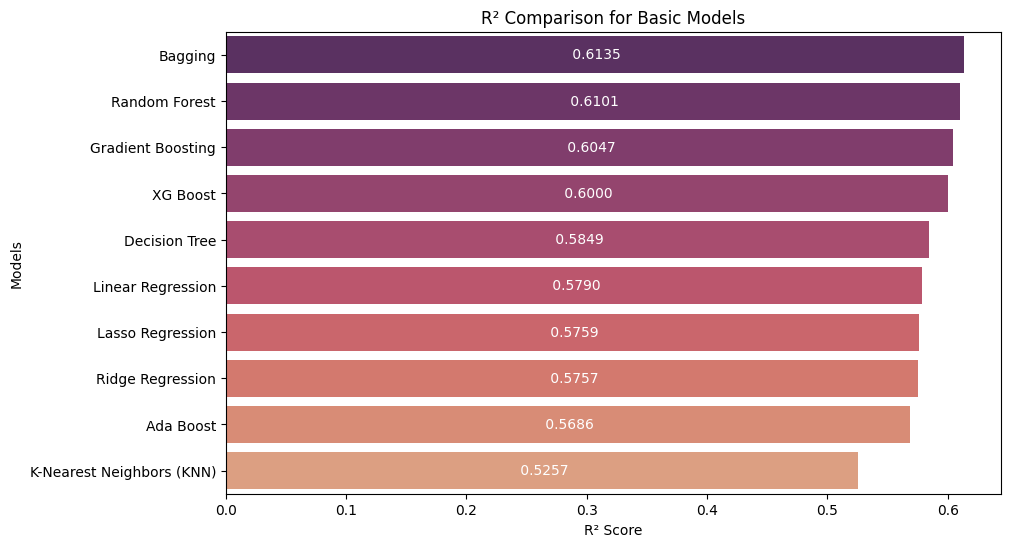

In [96]:
# Sorting models and R² scores in decreasing order
sorted_indices = np.argsort(r2_basic)[:: -1]
sorted_models = [models[i] for i in sorted_indices]
sorted_r2_basic = [r2_basic[i] for i in sorted_indices]

# Plotting the bar chart with labels
plt.figure(figsize = (10, 6))
sns.barplot(x = sorted_r2_basic, y = sorted_models, palette = "flare_r")
plt.title("R² Comparison for Basic Models")
plt.xlabel("R² Score")
plt.ylabel("Models")

# Adding the R² value labels
for i, r2 in enumerate(sorted_r2_basic):
    plt.text(r2 / 2, i, f"{r2 : .4f}", color = "white", ha = "center", va = "center")

plt.show()

The chart shows that **Bagging Regressor** has the highest $R^2$ score of **0.6135**, outperforming **Random Forest (0.6101)** and **Gradient Boosting (0.6047)**. This indicates that, without any tuning, Bagging Regressor explains the variance in the data better than the other models.

### **Plotting Comparison between the Tuned Models based on R² Score**

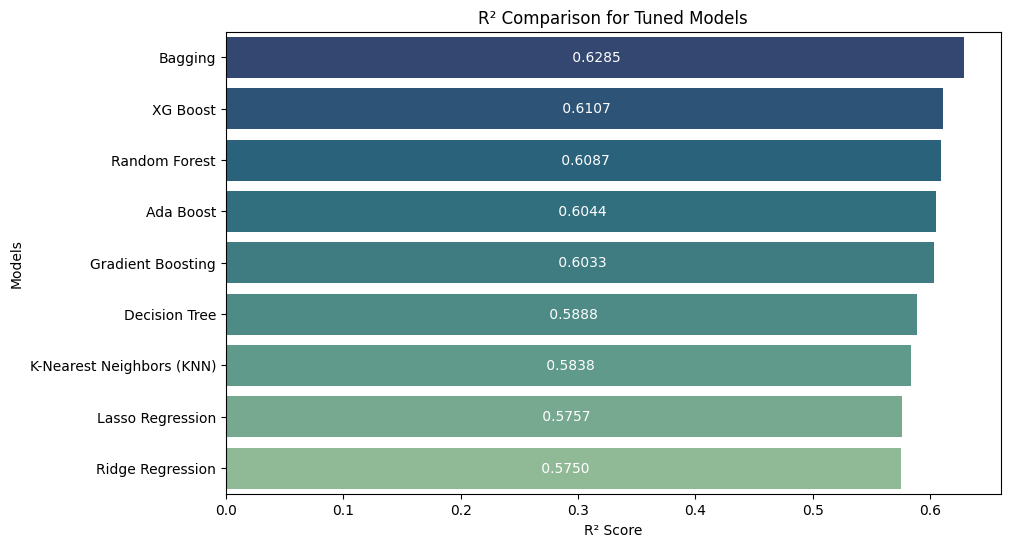

In [97]:
# Sorting tuned_models and R² scores in decreasing order
sorted_indices = np.argsort(r2_tuned)[:: -1]
sorted_models = [tuned_models[i] for i in sorted_indices]
sorted_r2_tuned = [r2_tuned[i] for i in sorted_indices]

# Plotting the bar chart with labels
plt.figure(figsize = (10, 6))
sns.barplot(x = sorted_r2_tuned, y = sorted_models, palette = "crest_r")
plt.title("R² Comparison for Tuned Models")
plt.xlabel("R² Score")
plt.ylabel("Models")

# Adding the R² value labels
for i, r2 in enumerate(sorted_r2_tuned):
    plt.text(r2 / 2, i, f"{r2 : .4f}", color = "white", ha = "center", va = "center")

plt.show()

After tuning, **Bagging Regressor** remains the top performer with an $R^2$ score of **0.6285**, surpassing **XG Boost (0.6107)** and **Random Forest (0.6087)**. This shows that Bagging Regressor continues to explain the variance in the data better than the other models even after optimization.

### **Plotting Comparison between the Basic Models based on MSE**

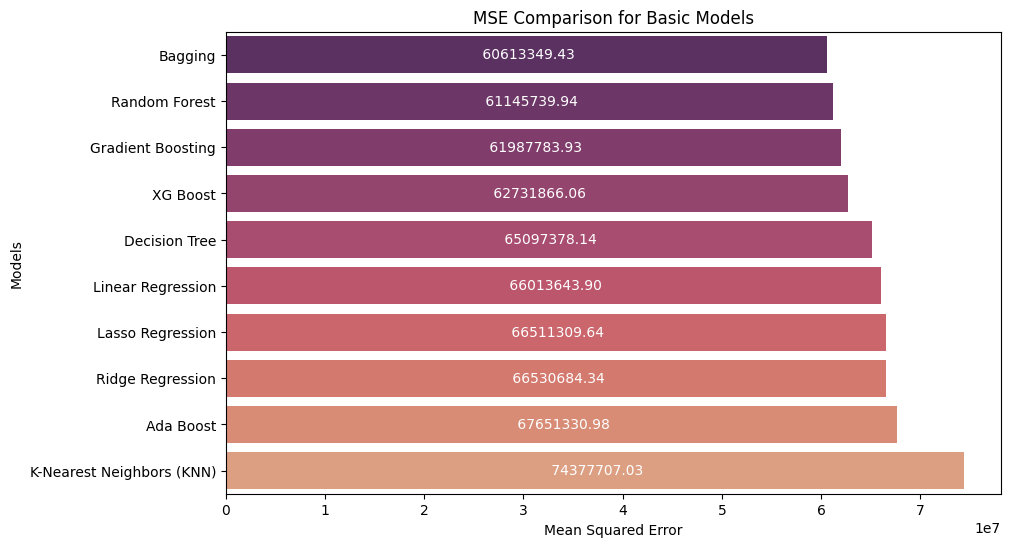

In [98]:
# Sorting models and MSE values in increasing order
sorted_indices = np.argsort(mse_basic)
sorted_models = [models[i] for i in sorted_indices]
sorted_mse_basic = [mse_basic[i] for i in sorted_indices]

# Plotting the bar chart with labels
plt.figure(figsize = (10, 6))
sns.barplot(x = sorted_mse_basic, y = sorted_models, palette = "flare_r")
plt.title("MSE Comparison for Basic Models")
plt.xlabel("Mean Squared Error")
plt.ylabel("Models")

# Adding the R² value labels
for i, mse in enumerate(sorted_mse_basic):
    plt.text(mse / 2, i, f"{mse : .2f}", color = "white", ha = "center", va = "center")

plt.show()

Without any tuning, **Bagging Regressor** has the lowest **Mean Squared Error (MSE)** of **60613349.43**, indicating the smallest average prediction error. It is followed by **Random Forest** with an MSE of **61145739.94** and **Gradient Boosting** with **61987783.93**. This suggests that Bagging Regressor provides the most accurate predictions among the models, with fewer errors overall.

### **Plotting Comparison between the Tuned Models based on MSE**

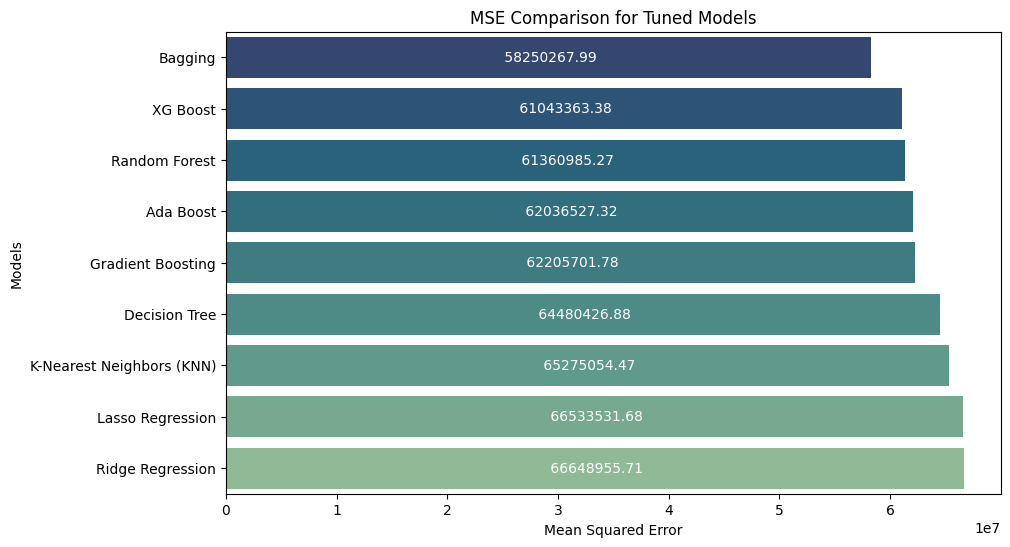

In [99]:
# Sorting tuned_models and MSE values in increasing order
sorted_indices = np.argsort(mse_tuned)
sorted_models = [tuned_models[i] for i in sorted_indices]
sorted_mse_tuned = [mse_tuned[i] for i in sorted_indices]

# Plotting the bar chart with labels
plt.figure(figsize = (10, 6))
sns.barplot(x = sorted_mse_tuned, y = sorted_models, palette = "crest_r")
plt.title("MSE Comparison for Tuned Models")
plt.xlabel("Mean Squared Error")
plt.ylabel("Models")

# Adding the R² value labels
for i, mse in enumerate(sorted_mse_tuned):
    plt.text(mse / 2, i, f"{mse : .2f}", color = "white", ha = "center", va = "center")

plt.show()

After tuning, **Bagging Regressor** achieves the lowest Mean Squared Error (MSE) of **58250267.99**, indicating the most accurate predictions with the least average error. It is followed by **XG Boost** with an MSE of **61043363.38** and **Random Forest** with **61360985.27**. This shows that Bagging Regressor remains the best model in terms of prediction accuracy, even after optimization.